In [2]:
%matplotlib inline

Best Score: 0.666373
Best Parameters: {'B': 0.02302251798764849, 'B_0': 0.0023551728628187895, 'mu_rolling': 0.07386927065461456}


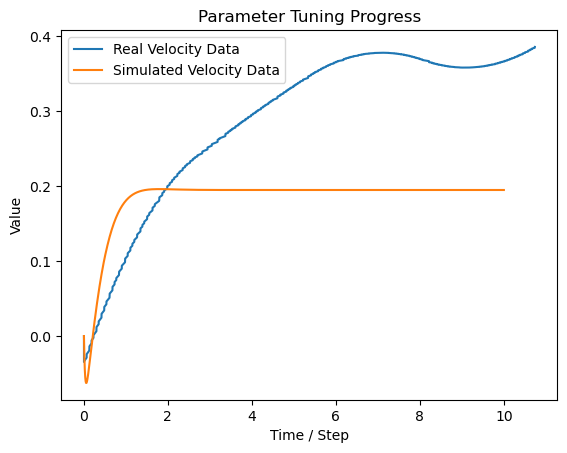

In [10]:
from Tuner import tune_parameters
from ParamTuners import ParamTuner, tuningPlotter, parse_mixed_csv, getPositionFromData, getVelocityFromData
from Runner import run_simulation
from Config import MODEL_T, CONTROL_STRATEGY, CONTROL_MODE


def simulate(result):
    run_simulation(
        initial_state=[0.0, 0.0, 0.0, 0.0],
        time_span=(0, 10),
        control_mode=CONTROL_MODE.VELOCITY,
        controller_type=CONTROL_STRATEGY.PD,
        desired_gamma=0.0,
        desired_velocity=0.5,
        desired_position=0.0,
        model_type=MODEL_T.ROLLING_RESISTANCE,
        record_Torque=False,
        export_CSV_flag=False,
        plot_results=False,
        export2list=result
    )

print("Loading real data from CSV...")

mode_segments = parse_mixed_csv("c:\\Users\\labuser\\Desktop\\unicycle_project_umich\\LOGS\\ValidLogs\\log_2026-04-01_14-20-46.533.csv")
data = None
for item in mode_segments:
    if item['mode'] == 'velocity':
        data = item['data'] # the last veloicity 

if data is None:
    print("Mode Segments:", mode_segments)
    raise ValueError("No velocity data found in the CSV file.")

realdata = getVelocityFromData(data)

def penaltyFunc(resultStorage):
    error = 0.0

    if realdata is None or len(realdata) == 0:
        raise ValueError("Real data is empty, cannot compute penalty.")
    if resultStorage is None or len(resultStorage) == 0:
        raise ValueError("Simulation result is empty, cannot compute penalty.")
    
    numeric_results = []

    tcolumn = resultStorage[0]  #  the first column is time
    vcolumn = resultStorage[1]  #  second column is velocity


    for t, v in zip(tcolumn, vcolumn):
        numeric_results.append((t, v))

    times = [t/100 for t in range(600,1000)] # 0 to 10 seconds with 0.01s intervals

    for t in times:
        closest_time_simu = min(numeric_results, key=lambda x: abs(x[0] - t))
        closest_time_real = min(realdata, key=lambda x: abs(x[0] - t))

        print(closest_time_simu, closest_time_real)

        # print(f"Time: {t:.2f} s, Simulated Velocity: {closest_time_simu[1]:.4f}, Real Velocity: {closest_time_real[1]:.4f}")

        error += (closest_time_simu[1] - closest_time_real[1]) ** 2



    # for time, real_vel in realdata:  # iterate through the real data samples
    #     if time < 9.9:  # only consider the first 10 seconds of data
    #         closest_time = min(numeric_results, key=lambda x: abs(x[0] - time))
    #         print("closest_time:", closest_time)
    #         sim_vel = closest_time[1]       
    #         # calculate the squared error
    #         error += (real_vel - sim_vel) ** 2
    
    #print(f"Current penalty (MSE): {error / len(realdata)}")
    return error / len(times)    



best_params = tune_parameters(paramDict ={'B': 0.018821967284210275, 'B_0': 0.0014464433962108783, 'mu_rolling': 0.028221652163219473},
                                simulation=simulate,
                                realdata=realdata,
                                ax_real_name="Real Velocity Data",
                                ax_try_name="Simulated Velocity Data",
                                penaltyFunc=penaltyFunc,
                                columnIndex = 2, # [x_c, x_c_dot, gamma, gamma_dot] we want to compare the velocity which is at index 2， (time is at 0)
                                max_iterations=50,
                                )